## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [91]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import os
import tarfile
import joblib # Imporxst joblib directly
from sklearn.datasets._base import _pkl_filepath, get_data_home
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as snsxs
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [92]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
dtype: int64
area    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   X             517 non-null    int64  
 1   Y             517 non-null    int64  
 2   FFMC          517 non-null    float64
 3   DMC           517 non-null    float64
 4   DC            517 non-null    float64
 5   ISI           517 non-null    float64
 6   temp          517 non-null    float64
 7   RH            517 non-null    int64  
 8   wind          517 non-null    float64
 9   rain          517 non-null    float64
 10  temp_squared  517 non-null    float64
 11  log_ISI       517 non-null    float64
dtypes: float64(9), int64(3)
memory usage: 48.6 KB
None
                X           Y        FFMC         DMC          DC    

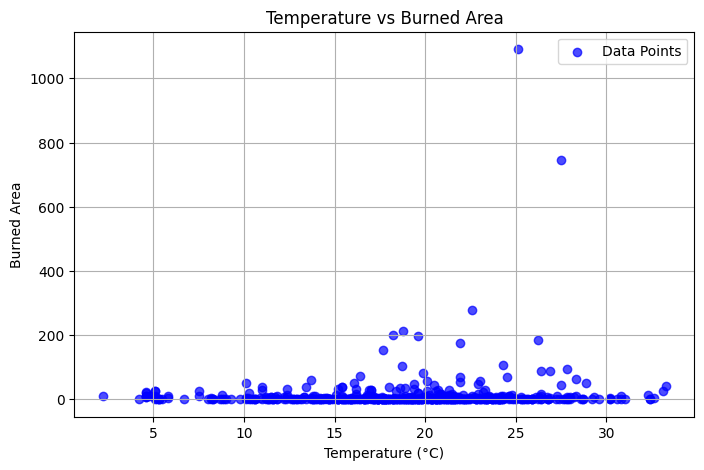

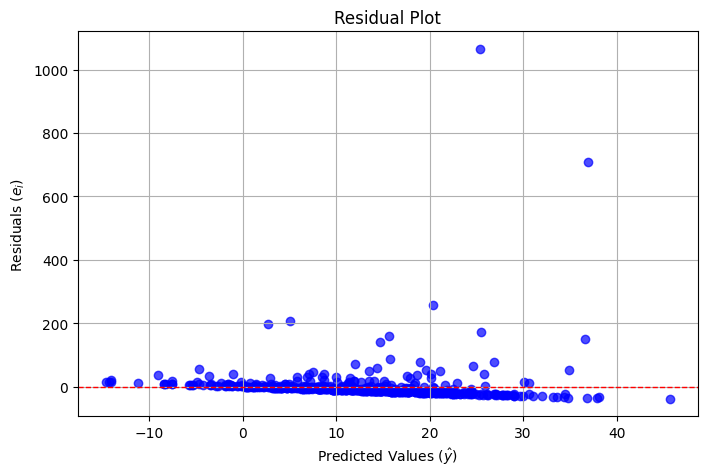

In [93]:
# Check missing values in X
print(X.isnull().sum())
# Check missing values in y
print(y.isnull().sum())


#display summary statistics and structure
print(X_num.info())
print(X_num.describe())
print(y.head())


#Select only numeric features (dropping 'month' and 'day' text columns)
numeric_features = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
X_num = X[numeric_features]


#Add constant
X_const = sm.add_constant(X_num)
model = sm.OLS(y, X_const).fit()


# Get predictions and residuals
y_pred = model.predict(X_const)
residuals = model.resid


#Plot scatterplot for a key predictor ('temp' vs target 'area')
plt.figure(figsize=(8, 5))
plt.scatter(X_num['temp'], y, color='blue', alpha=0.7, label='Data Points')
plt.title('Temperature vs Burned Area')
plt.xlabel('Temperature (°C)')
plt.ylabel('Burned Area')
plt.legend()
plt.grid(True)
plt.show()


#Residual plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color='blue', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residual Plot')
plt.xlabel(r'Predicted Values ($\hat{y}$)')
plt.ylabel(r'Residuals ($e_i$)')
plt.grid(True)
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [94]:
#fit the model
baseline_model = sm.OLS(y, X_num).fit()

# Transform the skewed target variable safely
y_log = np.log1p(y)

# Re-fit the OLS model using the log target and your numeric features
X_const = sm.add_constant(X_num)
model_log = sm.OLS(y_log, X_const).fit()

In [95]:
#check for quadratic transformations needed

for col in ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']:
    temp_df = pd.DataFrame({col: X_num[col], f'{col}_sq': X_num[col] ** 2})
    temp_df = sm.add_constant(temp_df)
    res = sm.OLS(y_log, temp_df).fit()
    
    p_val = res.pvalues[f'{col}_sq']
    
    if p_val < 0.05:
        significant_quadratics.append(col)
        print(f"✅ YES: {col} needs a quadratic term (p-value: {p_val:.4f})")
    else:
        print(f"❌ NO: {col} does not need it (p-value: {p_val:.4f})")


#quadratic transformation for temp
X_num['temp_squared'] = X_num['temp'] ** 2
nonlinear_model = smf.ols(formula='y_log ~ temp + temp_squared + wind + rain + RH + FFMC + DMC + DC + ISI', data=X_num).fit()

nonlinear_r_squared = nonlinear_model.rsquared
print(f'R-squared: {nonlinear_r_squared:.4f}')
print(nonlinear_model.summary())

❌ NO: FFMC does not need it (p-value: 0.6088)
❌ NO: DMC does not need it (p-value: 0.7960)
❌ NO: DC does not need it (p-value: 0.6898)
❌ NO: ISI does not need it (p-value: 0.4363)
✅ YES: temp needs a quadratic term (p-value: 0.0033)
❌ NO: RH does not need it (p-value: 0.6356)
❌ NO: wind does not need it (p-value: 0.7284)
❌ NO: rain does not need it (p-value: 0.1135)
R-squared: 0.0399
                            OLS Regression Results                            
Dep. Variable:                  y_log   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     2.338
Date:                Sat, 26 Sep 2026   Prob (F-statistic):             0.0138
Time:                        13:51:17   Log-Likelihood:                -895.96
No. Observations:                 517   AIC:                             1812.
Df Residuals:                     507   BIC:                

C:\Users\mesto\AppData\Local\Temp\ipykernel_15288\325806498.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_num['temp_squared'] = X_num['temp'] ** 2


In [96]:
# Check significant predictors again
sig_preds = model_log.pvalues[model_log.pvalues < 0.05]
print(sig_preds)
print("Shape:", sig_preds.shape)

interaction_model = smf.ols(formula='y_log ~ temp * wind + rain + RH + FFMC + DMC + DC + ISI', data = X_num).fit()

#extract and return r-squared
interaction_r_squared = interaction_model.rsquared
print(f'R-squared: {interaction_r_squared:.6f}')

#print summary
print(interaction_model.summary())

#FFMC, DMC, DC

wind    0.037188
dtype: float64
Shape: (1,)
R-squared: 0.027923
                            OLS Regression Results                            
Dep. Variable:                  y_log   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.618
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.107
Time:                        13:51:23   Log-Likelihood:                -899.15
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     507   BIC:                             1861.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [97]:
#indicator variables for month and day
#copy original dataset to add month and day back in
df_model = X.copy()

#Add the log-transformed target variable to this dataframe
df_model['y_log'] = np.log1p(y)

#Create the quadratic term for temperature
df_model['temp_squared'] = df_model['temp'] ** 2


#Fit the model
categorical_model = smf.ols(
    formula='y_log ~ C(month) + C(day) + temp + temp_squared + wind + rain + RH + FFMC + DMC + DC + ISI', 
    data=df_model
).fit()

#Print results
print(f'New R-squared: {categorical_model.rsquared:.4f}')
print(categorical_model.summary())

New R-squared: 0.0751
                            OLS Regression Results                            
Dep. Variable:                  y_log   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     1.531
Date:                Sat, 26 Sep 2026   Prob (F-statistic):             0.0467
Time:                        13:51:26   Log-Likelihood:                -886.28
No. Observations:                 517   AIC:                             1827.
Df Residuals:                     490   BIC:                             1941.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           

In [98]:
# Check skewness again
print(X_num.skew())

# Safely log-transform a feature that actually benefits from it (e.g., ISI)
df_model['log_ISI'] = np.log1p(df_model['ISI'])

# Fit model safely without breaking on rain
log_model = smf.ols(formula='y_log ~ log_ISI + C(month) + C(day)+ wind + rain + temp + RH + FFMC + DMC + DC', data=df_model).fit()
print(f'R-squared: {log_model.rsquared:.6f}')

#print summary
print(log_model.summary())

X                0.036246
Y                0.417296
FFMC            -6.575606
DMC              0.547498
DC              -1.100445
ISI              2.536325
temp            -0.331172
RH               0.862904
wind             0.571001
rain            19.816344
temp_squared     0.602660
dtype: float64
R-squared: 0.067683
                            OLS Regression Results                            
Dep. Variable:                  y_log   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.426
Date:                Sat, 26 Sep 2026   Prob (F-statistic):             0.0845
Time:                        13:51:29   Log-Likelihood:                -888.35
No. Observations:                 517   AIC:                             1829.
Df Residuals:                     491   BIC:                             1939.
Df Model:                          25          

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [ ]:
#check 2R^2 and  adjusted RR^2 for models
#nonlinear, categorical, log, interaction

# Assuming 'categorical_model' is your latest fitted model
print(f"Categorical: {categorical_model.rsquared:.4f}, {categorical_model.rsquared_adj:.4f}")
print(f"Nonlinear: {nonlinear_model.rsquared:.4f}, {nonlinear_model.rsquared_adj:.4f}")
print(f"Log: {log_model.rsquared:.4f}, {log_model.rsquared_adj:.4f}")
print(f"Interaction: {interaction_model.rsquared:.4f}, {interaction_model.rsquared_adj:.4f}")
#nonlinear and interaction have smalles gaps

Categorical: 0.0751, 0.0260
Nonlinear: 0.0399, 0.0228
Log: 0.0677, 0.0202
Interaction: 0.0279, 0.0107


In [100]:
# Compare AIC and BIC
print(f"Nonlinear -> AIC: {round(nonlinear_model.aic)}, BIC: {round(nonlinear_model.bic)}")
print(f"Categorical -> AIC: {round(categorical_model.aic)}, BIC: {round(categorical_model.bic)}")
print(f"Interaction -> AIC: {round(interaction_model.aic)}, BIC: {round(interaction_model.bic)}")
print(f"Log -> AIC: {round(log_model.aic)}, BIC: {round(log_model.bic)}")
#nonlinear lowest AIC and BIC

Nonlinear -> AIC: 1812, BIC: 1854
Categorical -> AIC: 1827, BIC: 1941
Interaction -> AIC: 1818, BIC: 1861
Log -> AIC: 1829, BIC: 1939


### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [101]:
#Ridge model
seed = 42

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_num, y_log, test_size=0.2, random_state=42)

# Ridge regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Predict and calculate MSE
ridge_pred = ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)
print(f"Ridge Test MSE: {ridge_mse}")
#pring ridge coefficient
print("Ridge Coefficients:", ridge.coef_)

Ridge Test MSE: 2.126495845508185
Ridge Coefficients: [ 0.04539493  0.00735622  0.02046638  0.00196893  0.00038284 -0.03757486
 -0.1481378  -0.00474294  0.03556792  0.0982665   0.00379713]


In [102]:
# Lasso regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

# Predict and calculate MSE
lasso_pred = lasso.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_pred)
print(f"Lasso Test MSE: {lasso_mse:.4f}")
#pring lasso coefficient
print("Lasso Coefficients:", lasso.coef_)

Lasso Test MSE: 2.1617
Lasso Coefficients: [ 0.03022442  0.          0.00926933  0.00197275  0.00016659 -0.0174363
 -0.0758899  -0.00301093  0.00131367  0.          0.00198701]


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [103]:
df_model = X.copy()
df_model['area'] = y

#fire occured binary
df_model['fire_occurred'] = (df_model['area'] > 0).astype(int) #0= recorded burned area, 1 = fire occured

#severity threshhold using the median 
threshold = df_model[df_model['area'] > 0]['area'].median()
df_model['is_large_fire'] = (df_model['area'] > threshold).astype(int) #0= small, 1 = large


logistic_model = smf.logit(
    formula='fire_occurred ~ temp + wind + RH + FFMC + DMC + DC + C(month)', 
    data=df_model
).fit()

print(logistic_model.summary())

         Current function value: 0.661155
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:          fire_occurred   No. Observations:                  517
Model:                          Logit   Df Residuals:                      499
Method:                           MLE   Df Model:                           17
Date:                Sat, 26 Sep 2026   Pseudo R-squ.:                 0.04479
Time:                        13:51:50   Log-Likelihood:                -341.82
converged:                      False   LL-Null:                       -357.85
Covariance Type:            nonrobust   LLR p-value:                   0.01481
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -3.5637      2.469     -1.444      0.149      -8.402       1.275
C(month)[T.aug]    -0.3412      1.177     -0.290  

c:\Users\mesto\anaconda3\envs\learn-env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [104]:
#Scale numeric features
numeric_features = ['temp', 'wind', 'RH', 'FFMC', 'DC']
scaler = StandardScaler()
X_scaled_num = pd.DataFrame(
    scaler.fit_transform(df_model[numeric_features]), 
    columns=numeric_features, 
    index=df_model.index
)

#Encode the categorical variables ('month' and 'day')
X_encoded_cats = pd.get_dummies(df_model[['month', 'day']], drop_first=True)

#Combine the scaled numeric features and the one-hot encoded dummies together
X_final = pd.concat([X_scaled_num, X_encoded_cats], axis=1)

# Define binary target variable
y_target = df_model['fire_occurred']
print(X_scaled.shape)

(517, 8)


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [106]:
# Train the Scikit-Learn Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_final, y_target)

#Check results
print(f"Model Coefficients: {model.coef_}:.4f")
print(f"Model Intercept: {model.intercept_[0]:.4f}")

Model Coefficients: [[ 1.80278902e-01  1.54172490e-01  4.10287798e-02  1.20175055e-01
   5.03108321e-02 -1.47516698e-01  1.64594831e+00  3.50174296e-01
  -3.15719959e-01  1.71155667e-02 -2.10062918e-01 -4.99021800e-01
   3.77625926e-02 -3.08072301e-01 -5.99895630e-01  8.15523273e-02
   1.68215816e-01  4.09839723e-02 -2.88351168e-02 -1.13697080e-03
   1.97098864e-01  3.07174118e-01]]:.4f
Model Intercept: 0.0695


In [108]:
#predict probabilities and binary outcomes
y_pred_prob = model.predict_proba(X_final)[:,1]
y_pred_class = model.predict(X_final)

print(y_pred_prob[:5])
print(y_pred_class[:5])

[0.33120415 0.34654301 0.29776155 0.33181668 0.29645807]
[0 0 0 0 0]


In [115]:
# Generate predictions on the test set first
y_pred_class = model.predict(X_final)

#Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.
print("--- Confusion Matrix ---")
print(confusion_matrix(y_target, y_pred_class))
print(f"Accuracy: {accuracy_score(y_target, y_pred_class):.4}")

#everything together
print("\n--- Full Classification Report ---")
print(classification_report(y_target, y_pred_class))

--- Confusion Matrix ---
[[105 142]
 [ 69 201]]
Accuracy: 0.5919

--- Full Classification Report ---
              precision    recall  f1-score   support

           0       0.60      0.43      0.50       247
           1       0.59      0.74      0.66       270

    accuracy                           0.59       517
   macro avg       0.59      0.58      0.58       517
weighted avg       0.59      0.59      0.58       517



### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [117]:
#Convert everything in X_final to float
X_vif_clean = X_final.astype(float)

#Ensure feature matrix has a constant (intercept) added 
X_vif_input = sm.add_constant(X_vif_clean)

#Compute VIF for every column
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_input.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_input.values, i) 
    for i in range(X_vif_input.shape[1])
]

#Round for readability and sort from highest to lowest VIF
vif_data["VIF"] = vif_data["VIF"].round(2)
print(vif_data.sort_values(by="VIF", ascending=False))

      Feature     VIF
0       const  130.73
16  month_sep   41.49
6   month_aug   36.64
5          DC   16.19
10  month_jul    7.31
12  month_mar    6.43
15  month_oct    5.64
1        temp    4.25
11  month_jun    3.52
8   month_feb    3.16
7   month_dec    2.71
3          RH    2.53
19    day_sun    1.81
4        FFMC    1.73
18    day_sat    1.73
17    day_mon    1.69
20    day_thu    1.61
21    day_tue    1.61
22    day_wed    1.53
9   month_jan    1.49
13  month_may    1.26
2        wind    1.23
14  month_nov    1.14


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

The area variable is very right skewed and has a lot of zeros in the data, from when there is no fire. I used log-transformations, quadradic terms, and interactions terms to help with this. However, even after these transformations, the models struggled to predict burned area with very low r-squared values. The binary classification helped with this. The logistic regression on fire_occured was more robust. This model found that weather and temperature were predictors for fires.

The simple OLS models are the easiest to interpret, but the model's performance is low. This could be due to the highly skewed area variable discussed previously. The regularized models (Ridge & Lasso) help with the multicollinearity in the data. These models helped especially with variables that measure similar things such as FFMC, DMC, and DC. But the model still has unpredictability for burned area. The logistic regression model isn't as precise of a measure for how much area the fire burned. However it gives a very good probability of fire and spread.

The best continuouse estimation is the ridge regression because it handles muliticollinearity and is better than the standard OLS. However, as discussed previously, the logistic regression model (fire_occured) paired with the scaled featrues provides a good probability for whether a fire will spread based on weather (temp, wind, RH, FFMC, and DC) and month.